# 04 — Training CNN + LSTM

---

## Objective

Train the primary image captioning model — **CNN encoder (ResNet50) + LSTM decoder** with teacher forcing.

- GPU only (mixed precision enabled)
- Model checkpoint (save best weights)
- Early stopping (prevent overfitting)
- Save training history and loss plots

## Theory

### Encoder–Decoder
The pre-trained ResNet50 (frozen) encodes an image into a **2048-d vector**. This vector is projected into the LSTM's initial hidden and cell states, "priming" the decoder with visual information.

### Teacher Forcing
At each step the decoder receives the **ground-truth previous word** (not its own prediction). This stabilises early training and speeds convergence.

### Masking
Padded positions in the caption sequences are masked so they contribute zero to the loss — the model only learns from real words.

## Imports

In [1]:
import os
import re
import pickle
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Dense, Dropout, Embedding, LSTM, Input
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, CSVLogger
)
from sklearn.model_selection import train_test_split

2026-07-01 02:08:21.551981: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-01 02:08:21.571537: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-01 02:08:21.591143: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-01 02:08:21.596121: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-01 02:08:21.609521: I tensorflow/core/platform/cpu_feature_guar

## GPU Setup

Enable memory growth and mixed precision.

In [2]:
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU:", gpus[0].name)
else:
    raise RuntimeError("GPU required for training.")

tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("Mixed precision:", tf.keras.mixed_precision.global_policy().name)
print("Policy compute dtype:", tf.keras.mixed_precision.global_policy().compute_dtype)

GPU: /physical_device:GPU:0
Mixed precision: mixed_float16
Policy compute dtype: float16


I0000 00:00:1782846503.538673  347650 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782846503.568955  347650 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782846503.571079  347650 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


## Configuration

In [3]:
CAPTIONS_PATH = "../dataset/captions.txt"
FEATURES_PATH = "../model/features.pkl"

OUTPUT_DIR = "../outputs/training/lstm"
os.makedirs(OUTPUT_DIR, exist_ok=True)

VOCAB_SIZE       = 5000
MAX_CAPTION_LEN  = 34
EMBEDDING_DIM    = 256
LSTM_UNITS       = 512
DROPOUT_RATE     = 0.5
BATCH_SIZE       = 64
EPOCHS           = 50
LEARNING_RATE    = 1e-3
RANDOM_SEED      = 42
TEST_SIZE        = 0.1       # 10 % validation

## Implementation

### 5.1 Load Data & Features

In [4]:
df = pd.read_csv(CAPTIONS_PATH)
print(f"Captions loaded: {len(df)}")

with open(FEATURES_PATH, "rb") as f:
    features = pickle.load(f)
print(f"Features loaded: {len(features)} images, "
      f"{list(features.values())[0].shape[0]} dims")

Captions loaded: 40455
Features loaded: 8091 images, 2048 dims


### 5.2 Clean Captions & Add Tokens

Same pipeline as notebook 02.

In [5]:
def clean_caption(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^a-z ]", "", text)
    return text.strip()

df["clean"] = df["caption"].apply(clean_caption)
df["clean"] = "<start> " + df["clean"] + " <end>"

print("Sample:")
print(df["clean"].iloc[0])

Sample:
<start> a child in a pink dress is climbing up a set of stairs in an entry way <end>


### 5.3 Build Tokenizer & Sequences

Fit tokenizer on **all** captions, then convert to padded integer sequences.

For teacher forcing:
- **Input**  = caption tokens `[0:n-1]` — includes `<start>`, excludes `<end>`
- **Target** = caption tokens `[1:n]`   — excludes `<start>`, includes `<end>`

In [6]:
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<oov>",
    filters=""
)
tokenizer.fit_on_texts(df["clean"])

vocab_size = min(len(tokenizer.word_index) + 1, VOCAB_SIZE)
print(f"Vocabulary size: {vocab_size}")

seq = tokenizer.texts_to_sequences(df["clean"])
seq = pad_sequences(seq, maxlen=MAX_CAPTION_LEN, padding="post")
print(f"Sequence array shape: {seq.shape}")

Vocabulary size: 5000
Sequence array shape: (40455, 34)


### 5.4 Train / Validation Split

Split by unique image so no data leakage between sets.

In [7]:
unique_images = df["image"].unique()
train_imgs, val_imgs = train_test_split(
    unique_images, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

train_mask = df["image"].isin(train_imgs)
val_mask   = df["image"].isin(val_imgs)

print(f"Train: {train_mask.sum():,} captions ({len(train_imgs):,} images)")
print(f"Val:   {val_mask.sum():,} captions ({len(val_imgs):,} images)")

Train: 36,405 captions (7,281 images)
Val:   4,050 captions (810 images)


### 5.5 Data Generator

`tf.data.Dataset` pipeline that yields `((image_features, input_seq), target_seq)` batches.

Teacher forcing format:
- `input_seq` = `seq[:, :-1]`  (length = MAX_CAPTION_LEN - 1)
- `target_seq` = `seq[:, 1:]`  (length = MAX_CAPTION_LEN - 1)

In [8]:
def create_dataset(mask, batch_size):
    img_names = df.loc[mask, "image"].values
    img_feats = np.array([features[name] for name in img_names], dtype=np.float32)

    cap_seq = seq[mask.values]
    input_seq  = cap_seq[:, :-1]
    target_seq = cap_seq[:, 1:]

    ds = tf.data.Dataset.from_tensor_slices(
        ((img_feats, input_seq), target_seq)
    )
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(train_mask, BATCH_SIZE)
val_ds   = create_dataset(val_mask,   BATCH_SIZE)

# Peek one batch
for (img_batch, cap_batch), target_batch in train_ds.take(1):
    print(f"Image feature batch: {img_batch.shape}")
    print(f"Caption input batch: {cap_batch.shape}")
    print(f"Target batch:        {target_batch.shape}")

I0000 00:00:1782846506.286576  347650 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782846506.288915  347650 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782846506.290599  347650 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782846506.382475  347650 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Image feature batch: (64, 2048)
Caption input batch: (64, 33)
Target batch:        (64, 33)


### 5.6 Build Model

Architecture:
- Image feature (2048,) → Dense → LSTM initial states
- Caption sequence → Embedding → LSTM (with image as initial state)
- Output projection → Dense(VOCAB_SIZE, softmax) at every timestep

In [9]:
img_input = Input(shape=(2048,), name="image_features")
x = Dense(EMBEDDING_DIM, activation="relu")(img_input)
x = Dropout(DROPOUT_RATE)(x)
initial_h = Dense(LSTM_UNITS, activation="tanh", name="initial_h")(x)
initial_c = Dense(LSTM_UNITS, activation="tanh", name="initial_c")(x)

cap_input = Input(shape=(MAX_CAPTION_LEN - 1,), name="caption")
x = Embedding(vocab_size, EMBEDDING_DIM, mask_zero=True)(cap_input)
x = LSTM(LSTM_UNITS, return_sequences=True)(x,
          initial_state=[initial_h, initial_c])
x = Dropout(DROPOUT_RATE)(x)
output = Dense(vocab_size, activation="softmax", name="output")(x)

model = Model(inputs=[img_input, cap_input], outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_features      │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ image_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption             │ (None, 33)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 33, 256)   │  1,280,000 │ caption[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_h (Dense)   │ (None, 512)       │    131,584 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_c (Dense)   │ (None, 512)       │    131,584 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 33, 512)   │  1,574,912 │ embedding[0][0],  │
│                     │                   │            │ initial_h[0][0],  │
│                     │                   │            │ initial_c[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 33, 512)   │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 33, 5000)  │  2,565,000 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,207,624 (23.68 MB)

 Trainable params: 6,207,624 (23.68 MB)

 Non-trainable params: 0 (0.00 B)

### 5.7 Compile

Adam optimizer with `global_clipnorm=5.0` for gradient stability.
Loss ignores masked (padded) positions automatically via `mask_zero=True`.

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE,
        global_clipnorm=5.0
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=False
    ),
    metrics=["accuracy"]
)
print("Model compiled.")

Model compiled.


### 5.8 Callbacks

- **ModelCheckpoint** — save only the best weights (lowest val_loss)
- **EarlyStopping** — stop if val_loss does not improve for 5 epochs
- **CSVLogger** — write epoch metrics to a CSV file for later plotting

In [11]:
checkpoint_path = os.path.join(OUTPUT_DIR, "lstm_best.keras")
history_path    = os.path.join(OUTPUT_DIR, "history.csv")

callbacks = [
    ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    CSVLogger(history_path),
]

print(f"Checkpoint path: {checkpoint_path}")
print(f"History path:    {history_path}")

Checkpoint path: ../outputs/training/lstm/lstm_best.keras
History path:    ../outputs/training/lstm/history.csv


### 5.9 Train

⚠️ This cell runs on GPU. Estimated time: **~10–30 minutes** depending on epochs.

In [12]:
start = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

elapsed = time.time() - start
print(f"\nTraining complete: {elapsed:.0f}s ({elapsed/60:.1f}m)")
print(f"Best val_loss: {min(history.history['val_loss']):.4f}")
print(f"Best val_accuracy: {max(history.history['val_accuracy']):.4f}")

Epoch 1/50


/home/fthasptr/miniconda3/envs/image-caption/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-07-01 02:08:28.924367: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
2026-07-01 02:08:29.613090: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


569/569 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3098 - loss: 4.0898
Epoch 1: val_loss improved from None to 3.41353, saving model to ../outputs/training/lstm/lstm_best.keras

Epoch 1: finished saving model to ../outputs/training/lstm/lstm_best.keras
569/569 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.3098 - loss: 4.0898 - val_accuracy: 0.3764 - val_loss: 3.4135
Epoch 2/50
568/569 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3813 - loss: 3.3003
Epoch 2: val_loss improved from 3.41353 to 3.13443, saving model to ../outputs/training/lstm/lstm_best.keras

Epoch 2: finished saving model to ../outputs/training/lstm/lstm_best.keras
569/569 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - accuracy: 0.3814 - loss: 3.2998 - val_accuracy: 0.4004 - val_loss: 3.1344
Epoch 3/50
569/569 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4011 - loss: 3.0603
Epoch 3: val_loss improved from 3.13443 to 2.96362, saving model to ../outputs/training/lstm/lstm_best.keras

Epoch 3: finished saving model to .

## Visualization

### 6.1 Training Curves

Loss and accuracy over epochs.

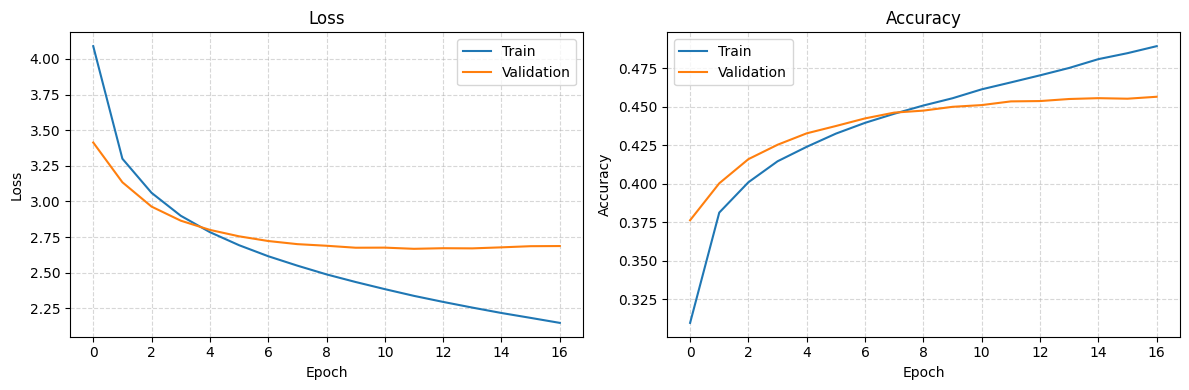

Plot saved to ../outputs/training/lstm/training_curves.png


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["loss"], label="Train")
ax1.plot(history.history["val_loss"], label="Validation")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(linestyle="--", alpha=0.5)

ax2.plot(history.history["accuracy"], label="Train")
ax2.plot(history.history["val_accuracy"], label="Validation")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, "training_curves.png")
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved to {plot_path}")

## Observation

- The LSTM decoder learns to generate plausible captions after the CNN encoder provides visual context
- Teacher forcing makes early epochs stable; during inference we'll switch to auto-regressive generation
- Best weights saved — these will be used for evaluation and inference
- If validation loss plateaus early, the model may benefit from more data or tuning

## Export

Save the tokenizer alongside the model so inference notebooks can decode predictions.

In [14]:
tokenizer_path = os.path.join(OUTPUT_DIR, "tokenizer.pkl")
with open(tokenizer_path, "wb") as f:
    pickle.dump(tokenizer, f)
print(f"Tokenizer saved to {tokenizer_path}")

history_df = pd.DataFrame(history.history)
history_csv = os.path.join(OUTPUT_DIR, "history.csv")
history_df.to_csv(history_csv, index=False)
print(f"Training history saved to {history_csv}")

Tokenizer saved to ../outputs/training/lstm/tokenizer.pkl
Training history saved to ../outputs/training/lstm/history.csv


## Next Step

→ **[05_train_gru.ipynb](05_train_gru.ipynb)** — Train the GRU baseline for comparison.